### Regression Metrics

- **MAE (Mean Absolute Error):** Measures average absolute prediction error; lower values are better, and values closer to 0 indicate good performance.
- **MSE (Mean Squared Error):** Measures squared prediction errors and penalizes large mistakes heavily; lower is better, but sensitive to outliers.
- **RMSE (Root Mean Squared Error):** Square root of MSE, interpretable in original target units; lower values indicate better model performance.
- **R² Score:** Measures how much variance the model explains; values closer to 1 are good, around 0 are poor, and negative values indicate very bad models.
- **Adjusted R²:** Improved version of R² that penalizes unnecessary features; higher values are better and useful when comparing models with different numbers of features.

### Formulas : 

| Metric | Formula |
| :--- | :--- |
| **MAE** | $\frac{1}{n} \sum \| y_i - \hat{y}_i \|$ |
| **MSE** | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ |
| **RMSE** | $\sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$ |
| **R²** | $1 - \frac{SS_R}{SS_M}$ |
| **Adj R²** | $1 - (1 - R^2)\frac{n - 1}{n - 1 - k}$ |

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [4]:
df = pd.read_csv('placement (1).csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [5]:
df.shape

(200, 2)

Text(0, 0.5, 'Package(in lpa)')

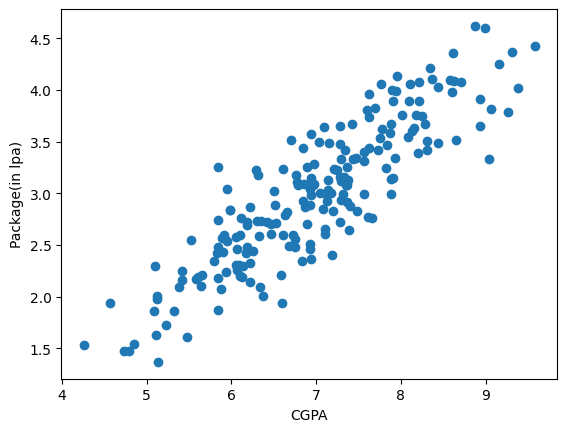

In [7]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [8]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [9]:
x

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [10]:
from sklearn.model_selection import train_test_split 
x_train , x_test ,y_train,y_test = train_test_split(x,y, test_size=0.2 , random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

Text(0, 0.5, 'Package(in lpa)')

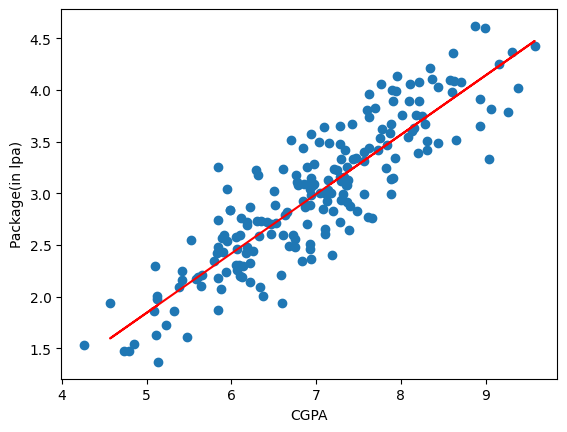

In [16]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [17]:
# Using Metrics class to import Regression metrices 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score 

In [23]:
# predicted Values 
y_pred = lr.predict(x_test)
y_pred

array([2.78031348, 3.13635249, 3.1995207 , 2.38981908, 3.52684689,
       3.76803461, 3.16506531, 2.54486832, 3.17655044, 3.4923915 ,
       1.90744364, 2.34962112, 3.6876387 , 2.75734322, 3.47516381,
       3.04447145, 2.32665086, 3.20526327, 2.17734418, 3.314372  ,
       2.45298729, 2.90090734, 3.32011456, 2.87219451, 3.33734226,
       2.19457187, 1.41932564, 2.7114027 , 3.18229301, 2.32665086,
       3.74506435, 2.95833298, 3.68189614, 2.97556068, 2.59080884,
       3.34882738, 2.47595755, 3.07318428, 4.17575671, 2.95833298])

In [24]:
# Og values
y_test.values

array([2.79, 3.23, 3.26, 3.04, 3.34, 4.21, 2.94, 2.87, 2.99, 3.58, 1.63,
       2.08, 4.08, 2.21, 3.47, 3.64, 2.74, 3.08, 2.17, 2.99, 2.31, 2.35,
       3.4 , 3.08, 3.81, 2.19, 1.53, 2.89, 3.16, 2.48, 3.51, 2.98, 3.39,
       3.28, 2.73, 3.74, 2.6 , 3.13, 3.82, 3.15])

In [27]:
# MAE  
print('MAE',mean_absolute_error(y_test,y_pred))       

MAE 0.23150985393278373


In [29]:
# MsE  
print('MSE',mean_squared_error(y_test,y_pred))       

MSE 0.08417638361329657


In [34]:
# RSME 
print('RMSE',np.sqrt(mean_squared_error(y_test,y_pred)))        

RMSE 0.2901316659954521


In [38]:
print("R2 Score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score 0.7730984312051673


In [39]:
# Adjusted R2 score
x_test.shape

(40, 1)

In [40]:
1 - ((1-r2)*(40-1)/(40-1-1))

0.7671273372895138

In [41]:
# Now lets see what if we add a new col(that relevent) & add a new col(thats irrelevent) to the data , and how it will affect the regression matric

### Adding Irrelevent col

In [42]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.534360,3.26
1,5.12,0.112740,1.98
2,7.82,0.393518,3.25
3,7.42,0.679879,3.67
4,6.94,0.454265,3.57


Text(0, 0.5, 'Package(in lpa)')

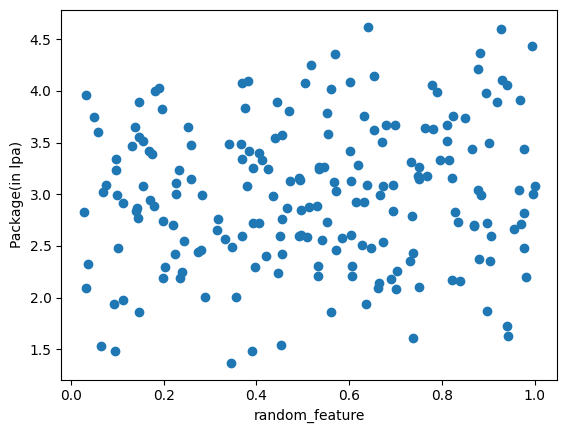

In [43]:
# Lets visualise 
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [44]:
x = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [45]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [48]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
y_pred = lr.predict(x_test)

In [51]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7832700272474137


In [52]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7715548935851118

### adding relevent col

In [53]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)
new_df2 = new_df2[['cgpa','iq','package']]

In [54]:
new_df2.sample(5)

,cgpa,iq,package
43,7.66,2.66,2.76
84,4.26,0.53,1.53
107,6.33,1.89,2.59
163,8.93,3.91,3.91
19,7.48,2.43,2.83


Text(0, 0.5, 'Package(in lpa)')

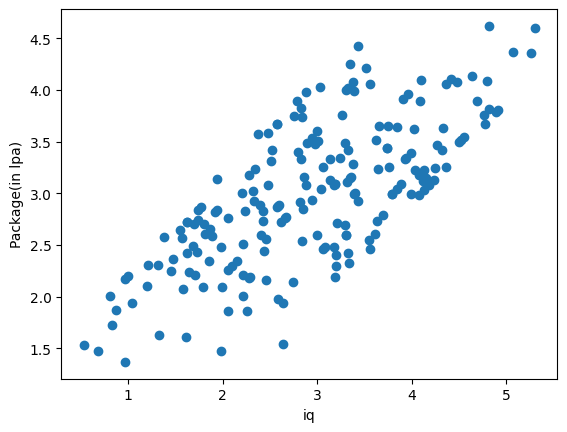

In [55]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [57]:
np.random.randint(-100,100)

-4

In [58]:
x = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [59]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [60]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [61]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8283743139950759


In [76]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8190972498867016